# TP : Classification des transactions bancaires

Vous etes data Scientist dans le departement data d'une banque. 
On sollicite vos services pour crée un modele capable de classé les transactions bancaire en transactions frauduleuses ou non, 
a partir du jeux de données.
Le dataset contient des variables comme:Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent(categorielles et numérique).
La variable cible Fraudulent 0-Transaction non frauduleuse - 1- Transaction frauduleuse



## Problématique métier

Le service Data d'une banque vous contacte pour les aider a réduire le taux d'erreur lors de la classifications de transactions frauduleuse:

> *«  Votre mission est d'analyser le dataset **Détection de fraude à la carte de crédit — Kaggle**, 
de préparer les données, de construire et d'évaluer un modèle de **régression logistique** 
afin de répondre à la question suivante : »*

> *À partir des caractéristiques de la transaction peut on prédire avec précision si la transaction est une fraude ou non?*

**Livrables attendus :**
- Une analyse exploratoire des données
- Un modèle de classification entraîné et évalué
- Une interprétation claire des résultats et des métriques


## Description des données

Nous utilisons le dataset **Détection de fraude à la carte de crédit — Kaggle** disponible sur Kaggle. Il comprend :
- **51000 observations** de transactions bancaires
- **12 caractéristiques categorielles numériques** 
- **Variable cible** : `fraudulent` — 1 = Cas de fraude, 0 = Pas de cas de fraude

## Phase 0 — Installation et Imports

Importez toutes les librairies nécessaires pour ce TP.

> **Librairies attendues :** `numpy`, `pandas`, `matplotlib`, `seaborn`, et les modules scikit-learn suivants : `datasets`, `model_selection`, `tree`, `metrics`.

In [2]:
# TODO : Importez les librairies nécessaires pour 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO : Activez les réglages d'affichage si besoin (ex. : warnings, affichage pandas)

pd.set_option('display.max_columns', None)

## Phase 1 — Business Understanding

### Contexte
Vous êtes data scientist dans la branche Data de la banque.

### Objectif
Développer un modèle d'arbre de décision capable de prédire si une transaction bancaire est frauduleuse ou non.

### Questions métier à résoudre

1. Peut-on prédire de manière fiable la nature fraude/pas fraude d'une transaction ?
2. Quelles sont les caractéristiques médicales les plus importantes pour cette prédiction ?
3. Le modèle peut-il aider à réduire les erreurs de classification de 20 % mentionnées par le client ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Classification binaire |
| **Variable cible Y** | `fraudulent` (0 = Cas de fraude, 1 = Pas de cas de fraude) |
| **Variables explicatives X** | 12 caractéristiques numériques et catgorielles|
| **Métrique principale** | Accuracy, précision, rappel (recall) |

---

> **À compléter :** Un modele d'arbre de décisio peut il aider la banque a réduire son taux d'erreur lors de la classification des transactions bancaires ?

**Votre réponse ici :**

_« Oui un model d'arbre de décision peut effectivement réduire le taux d'erreur de la banque lors de la classification des transations bancaire »_

## Phase 2 — Data Understanding

### 2.1 Chargement des données



In [3]:
# TODO : Chargez le dataset Fraud Detection Dataset.csv dans un DataFrame
df = pd.read_csv('Fraud Detection Dataset.csv')


### 2.2 Exploration initiale

Faites une première inspection du dataset : dimensions, types, aperçu des données.

In [4]:
# TODO : Faites une copie du dataset pour conserver l'original
df_copy = df.copy()
# TODO : Affichez les premières lignes pour inspection
df_copy.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [5]:
# TODO : Affichez la dimension du dataset (nombre de lignes et de colonnes)
print(f"Les dimensions du dataset sont : {df_copy.shape}")
# TODO : Affichez les types de chaque colonne
print(f"Les types de données sont : {df_copy.dtypes}")

Les dimensions du dataset sont : (51000, 12)
Les types de données sont : Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object


### 2.3 Distribution de la variable cible

Analysez la répartition des classes (maligne vs bénigne) pour détecter un éventuel déséquilibre.

In [6]:
# TODO : Calculez le nombre et le pourcentage d'échantillons par classe (fraude / pas fraude)
class_counts = df_copy['Fraudulent'].value_counts()
class_percentages = df_copy['Fraudulent'].value_counts(normalize=True) * 100
# TODO : Affichez ces résultats de manière lisible
print("Nombre d'échantillons par classe :")
print(class_counts)
print("\nPourcentage d'échantillons par classe :")
print(class_percentages)

Nombre d'échantillons par classe :
Fraudulent
0    48490
1     2510
Name: count, dtype: int64

Pourcentage d'échantillons par classe :
Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64


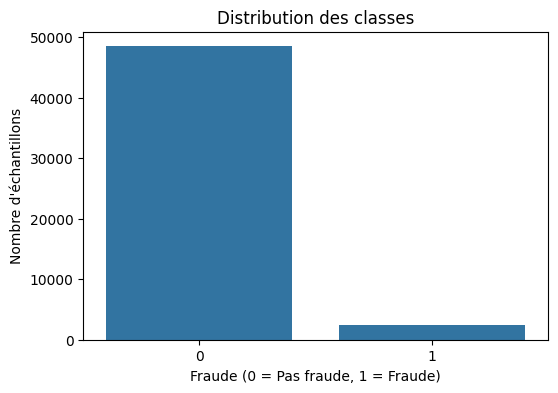

In [7]:
# TODO : Visualisez la distribution des classes avec un graphique adapté (countplot ou pie)
plt.figure(figsize=(6, 4))
sns.countplot(x='Fraudulent', data=df_copy)
# TODO : Utilisez des labels clairs ('Fraude', 'Pas fraude') plutôt que les codes 0/1
plt.xlabel('Fraude (0 = Pas fraude, 1 = Fraude)')
plt.ylabel('Nombre d\'échantillons')
plt.title('Distribution des classes')
plt.show()

### 2.4 Analyse des valeurs manquantes

Vérifiez s'il y a des valeurs manquantes dans le dataset avant de continuer.

In [8]:
# TODO : Vérifiez les valeurs manquantes par colonne
missing_values = df_copy.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_values)
# TODO : Affichez uniquement les colonnes qui en contiennent (si applicable)


Valeurs manquantes par colonne :
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


### On remarque qu'il ya des variables manquantes dans le dataset

### 2.5 Statistiques descriptives

Analysez les statistiques des variables numériques et identifiez les variations importantes entre les caractéristiques.

> Observez les moyennes, écarts-types et plages de valeurs. Certaines variables ont-elles des échelles très différentes ?

In [9]:
# TODO : Affichez les statistiques descriptives complètes (mean, std, min, max, quartiles)
print("Statistiques descriptives :")
#df_copy.describe()
# TODO : Transposez le résultat si nécessaire pour une meilleure lisibilité
print("\nStatistiques descriptives transposées :")
df_copy.describe().T


Statistiques descriptives :

Statistiques descriptives transposées :


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.00,4999.0
Transaction_Amount,48480.0,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Time_of_Transaction,48448.0,11.488400,6.922954,0.00,5.0000,12.0,17.00,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.00,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.00,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.00,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.00,1.0


### 2.6 Visualisation comparative fraude vs pas fraude

Pour comprendre le pouvoir discriminant des variables, visualisez la distribution de plusieurs caractéristiques **selon la classe cible**.

> C'est une étape clé du Data Understanding : si les distributions des deux classes se chevauchent fortement, la variable sera peu utile pour la classification.



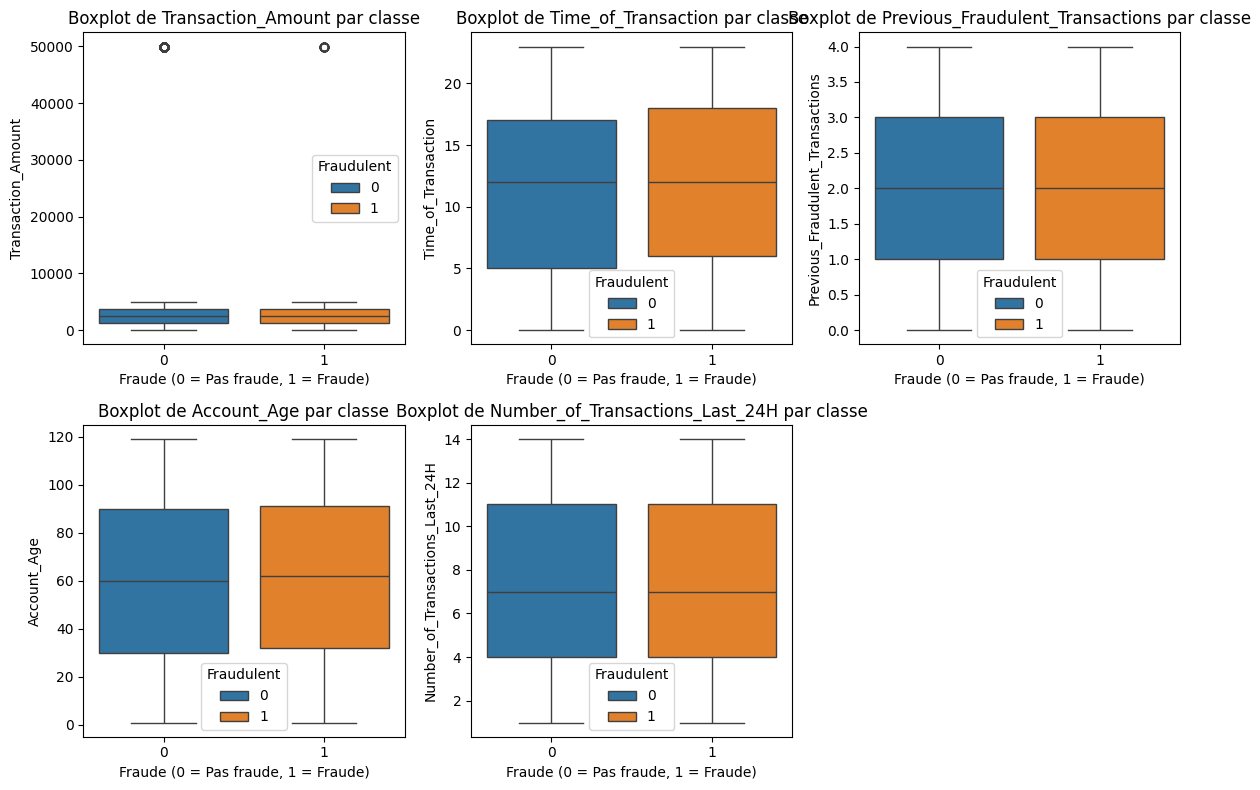

In [10]:
# TODO : Créez des boxplots comparatifs pour 4 à 6 caractéristiques importantes
cols_to_plot = ['Transaction_Amount','Time_of_Transaction','Previous_Fraudulent_Transactions','Account_Age','Number_of_Transactions_Last_24H']  # Remplacez par les caractéristiques pertinentes
plt.figure(figsize=(12, 8))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i + 1)  # Organisez les graphiques en grille (2 lignes × 3 colonnes)
    sns.boxplot(x='Fraudulent', y=col, data=df_copy,hue='Fraudulent')
    plt.title(f'Boxplot de {col} par classe')
    plt.xlabel('Fraude (0 = Pas fraude, 1 = Fraude)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()
# TODO : Séparez les boxplots par classe (fraude vs pas fraude)
# TODO : Organisez les graphiques en grille (ex. : 2 lignes × 3 colonnes)


### 2.7 Corrélations

Étudiez les relations entre les variables pour identifier les redondances et les variables fortement liées à la cible.

Numériques: ['User_ID', 'Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Fraudulent']
Catégorielles: ['Transaction_ID', 'Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


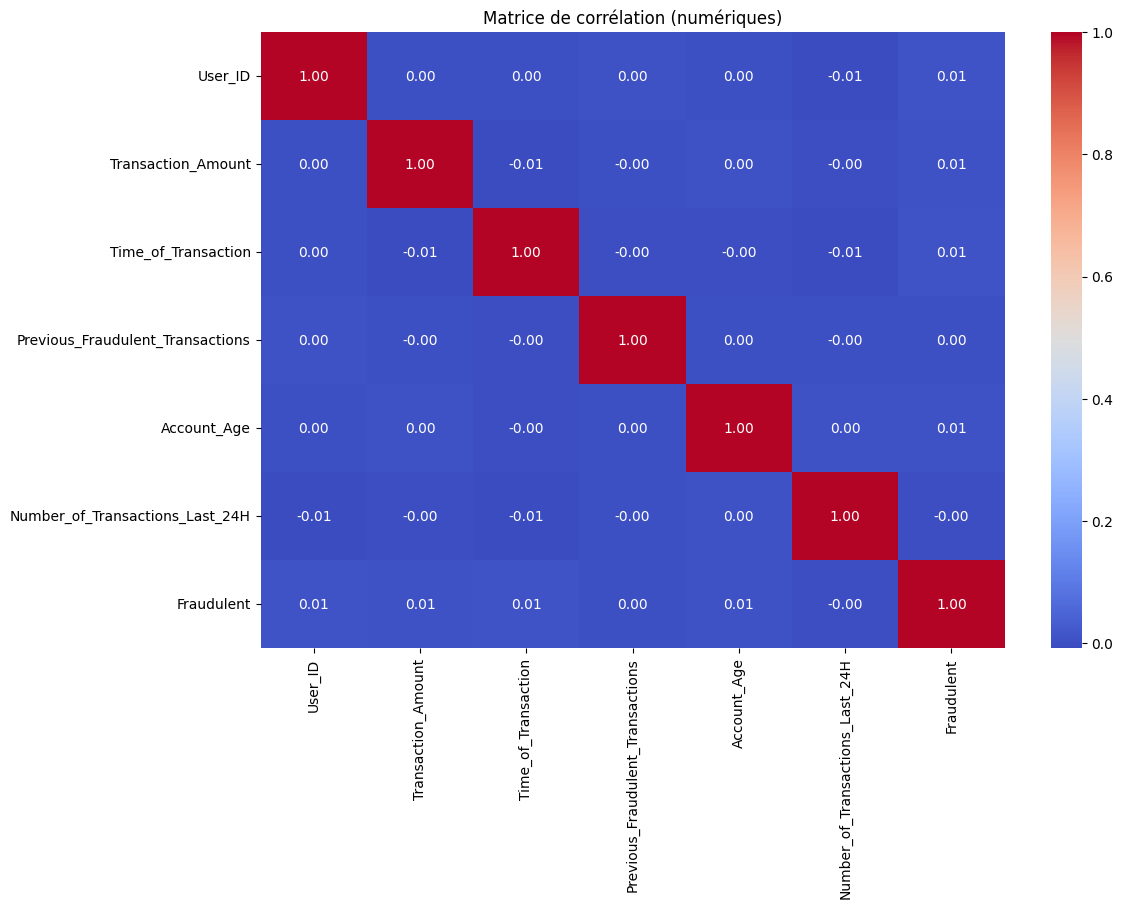

Corrélation des variables avec la cible 'Fraudulent' :
Fraudulent                          1.000000
User_ID                             0.008046
Time_of_Transaction                 0.007035
Account_Age                         0.006203
Transaction_Amount                  0.005507
Number_of_Transactions_Last_24H     0.003877
Previous_Fraudulent_Transactions    0.001136
Name: Fraudulent, dtype: float64


In [12]:
# TODO : Calculez et visualisez la matrice de corrélation (heatmap)
num_cols = [c for c in df_copy.select_dtypes(include=[np.number]).columns.tolist()]
cat_cols = df_copy.select_dtypes(include=['object','category']).columns.tolist()
print('Numériques:', num_cols)
print('Catégorielles:', cat_cols)
df_copy[num_cols].describe().T


#Matrice de corrélation:
plt.figure(figsize=(12,8))
corr = df_copy[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation (numériques)')
plt.show()
# TODO : Identifiez les variables les plus corrélées à 'target'

corr_target= corr['Fraudulent'].abs().sort_values(ascending=False)
print("Corrélation des variables avec la cible 'Fraudulent' :")
print(corr_target)
# TODO : Commentez les corrélations fortes entre variables explicatives (multicolinéarité)


### D'après les corémations les variables les plus corrélés avec la variable cible sont:
-`Time_of_Transaction                 0.007035`

-`Account_Age                         0.006203`

-`Transaction_Amount                  0.005507`

-`Number_of_Transactions_Last_24H     0.003877`

-`Previous_Fraudulent_Transactions    0.001136`

_La variable UserId est corrélé avec la cible mais en étudiant le dataset on se rend compte que la corrélation n'est pas informative_


### Analyse des variables numériques et catégorielles

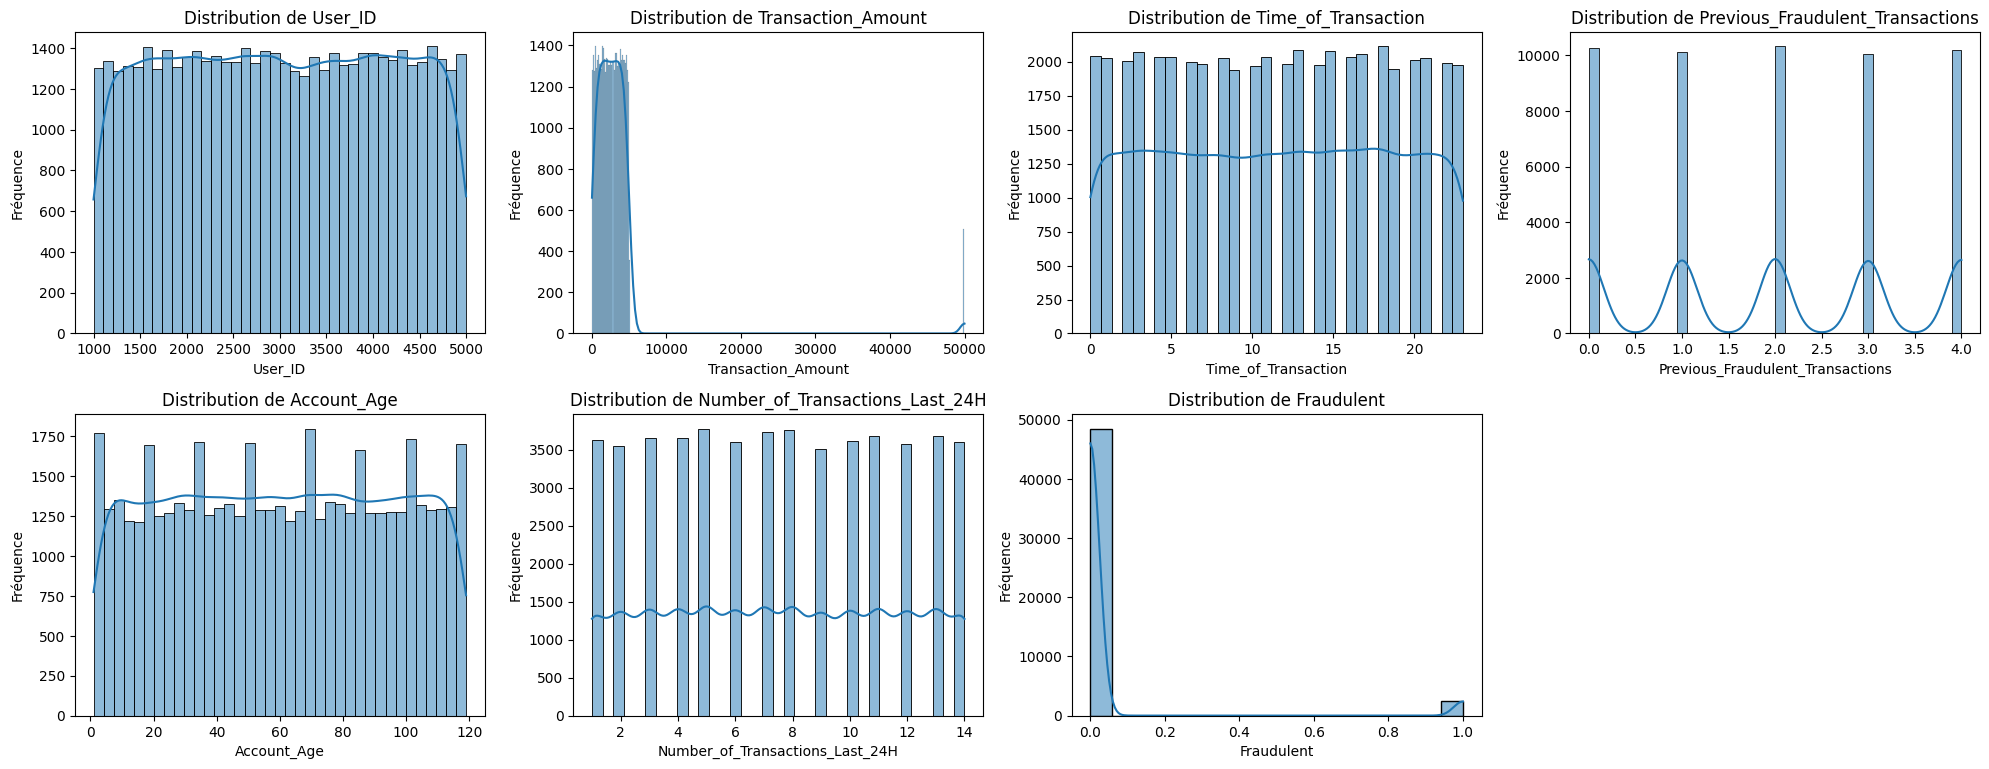

In [13]:
#Etude des distributions des variables numériques
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)  # Organisez les graphiques en grille (4 lignes × 4 colonnes)
    sns.histplot(df_copy[col], kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

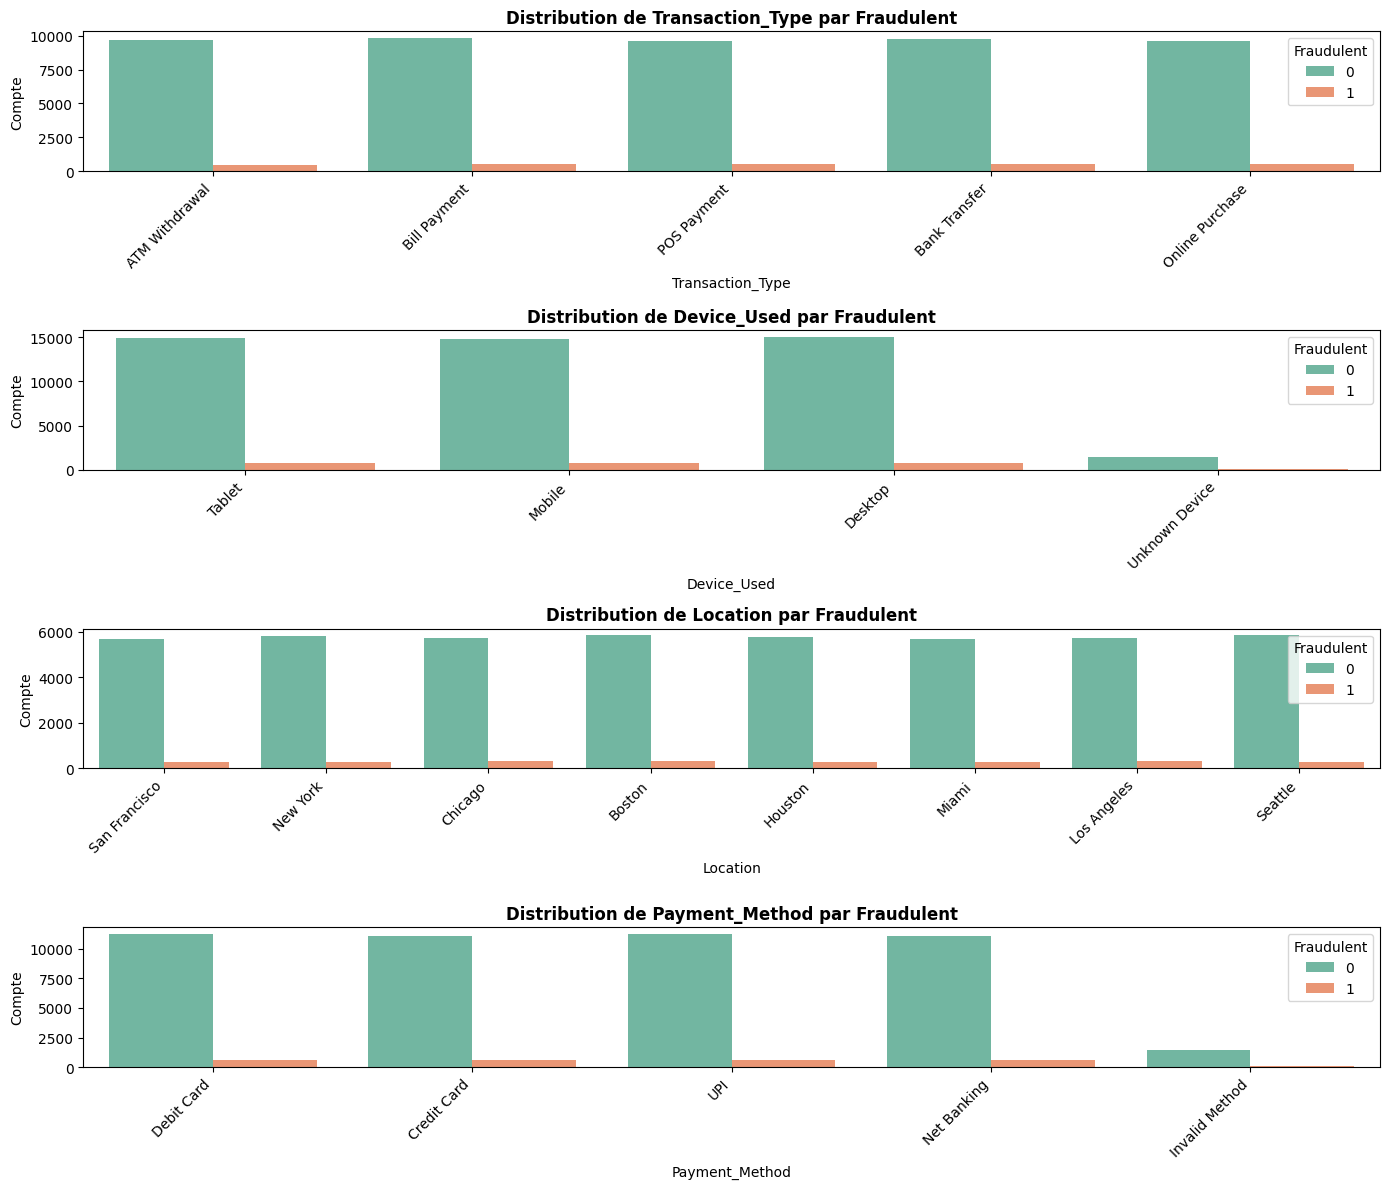


 Taux de souscription par modalité (top features) :

TRANSACTION_TYPE :
Fraudulent        yes_rate
Transaction_Type          
ATM Withdrawal           0
Bank Transfer            0
Bill Payment             0
Online Purchase          0
POS Payment              0
All                      0

DEVICE_USED :
Fraudulent      yes_rate
Device_Used             
Desktop                0
Mobile                 0
Tablet                 0
Unknown Device         0
All                    0

LOCATION :
Fraudulent     yes_rate
Location               
Boston                0
Chicago               0
Houston               0
Los Angeles           0
Miami                 0
New York              0
San Francisco         0
Seattle               0
All                   0

PAYMENT_METHOD :
Fraudulent      yes_rate
Payment_Method          
Credit Card            0
Debit Card             0
Invalid Method         0
Net Banking            0
UPI                    0
All                    0


In [76]:
#Variables categorielle d'Interet 
vars_=['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

fig, axes = plt.subplots(len(vars_), 1, figsize=(14, 3 * len(vars_)))
if len(vars_) == 1:
    axes = [axes]

for idx, var in enumerate(vars_):
    ax = axes[idx]
    sns.countplot(data=df_copy, x=var, hue='Fraudulent', ax=ax, palette='Set2')
    ax.set_title(f'Distribution de {var} par Fraudulent', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Compte')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Taux de souscription par modalité
print("\n Taux de souscription par modalité (top features) :")
for var in vars_:
    print(f"\n{var.upper()} :")
    crosstab = pd.crosstab(df_copy[var], df_copy['Fraudulent'], margins=True, normalize='index') * 100
    crosstab['yes_rate'] = crosstab.get('yes', 0)
    crosstab = crosstab.sort_values('yes_rate', ascending=False)
    print(crosstab[['yes_rate']].round(1))


In [14]:
#Etude des variables categorielles
#crosstabulation entre 'Fraudulent' et les variables catégorielles
for col in cat_cols:
    print("valeurs uniques de la variable : ",col, " : ", df_copy[col].unique())
    print(f"{df_copy[col].value_counts()}\n ")


valeurs uniques de la variable :  Transaction_ID  :  ['T1' 'T2' 'T3' ... 'T49998' 'T49999' 'T50000']
Transaction_ID
T21614    2
T10897    2
T12008    2
T1004     2
T5        2
         ..
T49996    1
T49997    1
T49998    1
T49999    1
T50000    1
Name: count, Length: 50000, dtype: int64
 
valeurs uniques de la variable :  Transaction_Type  :  ['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
Transaction_Type
Bill Payment       10340
Bank Transfer      10276
ATM Withdrawal     10164
POS Payment        10126
Online Purchase    10094
Name: count, dtype: int64
 
valeurs uniques de la variable :  Device_Used  :  ['Tablet' 'Mobile' 'Desktop' nan 'Unknown Device']
Device_Used
Desktop           15795
Mobile            15614
Tablet            15588
Unknown Device     1530
Name: count, dtype: int64
 
valeurs uniques de la variable :  Location  :  ['San Francisco' 'New York' nan 'Chicago' 'Boston' 'Houston' 'Miami'
 'Los Angeles' 'Seattle']
Location
Boston       

### Traitement des données
- Gérer les valeurs manquantes
- Gérer les outliers (IQR)
- Encodage des variables catégorielles

## Phase 3 — Data Preparation

### 3.1 Séparation des variables

Séparez les variables explicatives (X) et la variable cible (y).

- Les colones Transaction_ID et User_ID a beaucoup de valeurs unique mais n'apporte pas vraiment d'informations dans la suite nous choisiront de les supprimer

In [26]:
num_cols = [c for c in df_copy.select_dtypes(exclude='object').columns.tolist()]
cat_cols = df_copy.select_dtypes(include='object').columns.tolist()

#Traitement des valeurs manquantes:
#Remplacer les valeurs manquantes par la mediane
for c in num_cols:
    if df_copy[c].isna().any():
        df_copy[c] = df_copy[c].fillna(df_copy[c].median())

#Remplacer les valeurs manquantes par le mode
for c in cat_cols:
    if df_copy[c].isna().any():
        df_copy[c] = df_copy[c].fillna(df_copy[c].mode())

#Les valeurs abérantes ne sont pas fréquentes donc on peut negliger leurs
#traitement a cette étape de l'analyse


In [20]:
df_copy=df_copy.drop('Transaction_ID',axis=1)
df_copy=df_copy.drop('User_ID',axis=1)

In [27]:
df_copy.head()

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,2395.02,ATM Withdrawal,12.0,Mobile,NaN,3,115,9,NaN,0
3,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [28]:
df_copy.isna().sum()

Transaction_Amount                     0
Transaction_Type                       0
Time_of_Transaction                    0
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [29]:
#Encodage des variables catégorielles
# 3) Encodage: get_dummies pour les catégorielles (drop_first=True)
df_enc = pd.get_dummies(df_copy, columns=cat_cols, drop_first=True)
print('Après encodage shape:', df_enc.shape)


Après encodage shape: (51000, 24)


In [30]:
# TODO : Définissez X (les 30 caractéristiques) et y (la colonne 'class')


X= df_enc.drop('Fraudulent', axis=1)
y= df_enc['Fraudulent']
# TODO : Vérifiez les dimensions de X et y
print(f"Les dimensions de X sont : {X.shape}")
print(f"Les dimensions de y sont : {y.shape}")

Les dimensions de X sont : (51000, 23)
Les dimensions de y sont : (51000,)


### 3.2 Normalisation : nécessaire ou non ?

> **Question de réflexion :** Les arbres de décision ont-ils besoin d'une normalisation des variables ? Justifiez votre réponse en expliquant comment un arbre prend ses décisions.



**Votre réponse ici :**

> **Réponse:** Non les arbres de décisions n'ont pas forcements besoin d'une normalisation puisse qu'il prenent leurs décisions en calculant un indice puis en divaisant les classes suivant cet indice.

### 3.3 Séparation train / test

Divisez les données en ensembles d'entraînement (80 %) et de test (20 %).

In [31]:
# TODO : Séparez les données en train/test (80/20)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# TODO : Utilisez une stratification sur y pour conserver les proportions de classes
# TODO : Fixez random_state=42 pour la reproductibilité


In [33]:
# TODO : Vérifiez que les proportions de classes sont bien conservées dans train et test
print("Proportions de classes dans y_train :")
print(y_train.value_counts(normalize=True) * 100)
print("\nProportions de classes dans y_test :")
print(y_test.value_counts(normalize=True) * 100)
# TODO : Affichez les pourcentages de chaque classe dans X_train et X_test


Proportions de classes dans y_train :
Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64

Proportions de classes dans y_test :
Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64


### On remarque que les classes de la target son très déséqulibrés ce qui suppose de faire un réequilibrage pour permettre au model d'apprendre convenablement

In [63]:
#Gestion du déséquilibre des classes 
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
X_test, y_test = smote.fit_resample(X_test, y_test)
#SMOTE est une technique de suréchantillonnage qui génère de nouveaux échantillons synthétiques pour la classe minoritaire afin d'équilibrer les classes dans le jeu de données d'entraînement.
# En appliquant SMOTE, nous pouvons améliorer les performances du modèle en fournissant plus d'exemples de la classe minoritaire, ce qui peut aider à réduire le biais du modèle envers la classe majoritaire.   

print("Proportions de classes dans y_train_resampled :")
print(y_train_resampled.value_counts(normalize=True) * 100)
print("\nProportions de classes dans y_test_resampled :")
print(y_test.value_counts(normalize=True) * 100)

Proportions de classes dans y_train_resampled :
Fraudulent
0    50.0
1    50.0
Name: proportion, dtype: float64

Proportions de classes dans y_test_resampled :
Fraudulent
0    50.0
1    50.0
Name: proportion, dtype: float64


## Phase 4 — Modeling

### 4.1 Modèle 1 : Arbre avec critère Gini

Entraînez un premier arbre de décision avec le critère Gini.

In [64]:
# TODO : Créez un DecisionTreeClassifier avec criterion='gini' et max_depth=3
from sklearn.tree import DecisionTreeClassifier

model1 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42) 
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement
model1.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.2 Modèle 2 : Arbre avec critère Entropie

Entraînez un deuxième arbre de décision avec le critère Entropie (gain d'information).

In [65]:
# TODO : Créez un DecisionTreeClassifier avec criterion='entropy' et max_depth=3
model2= DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement
model2.fit(X_train_resampled, y_train_resampled)


,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.3 Modèle 3 : Arbre sans contrainte de profondeur

Entraînez un troisième arbre **sans limiter la profondeur** pour observer le surapprentissage.

> Un arbre sans contrainte va mémoriser parfaitement les données d'entraînement. Ce modèle servira de comparaison pour comprendre l'importance du paramètre `max_depth`.

In [66]:
# TODO : Créez un DecisionTreeClassifier SANS max_depth (laissez l'arbre croître librement)
model3= DecisionTreeClassifier(criterion='gini', random_state=42)
# TODO : Entraînez-le sur l'ensemble d'entraînement
model3.fit(X_train_resampled, y_train_resampled)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Phase 5 — Evaluation

### 5.1 Comparaison des trois modèles

Évaluez les performances des trois modèles sur le train et le test.

In [67]:
# TODO : Pour chacun des 3 modèles, calculez l'accuracy sur X_train et X_test
from sklearn.metrics import accuracy_score
accuracy_train_model1 = accuracy_score(y_train_resampled, model1.predict(X_train_resampled))
accuracy_test_model1 = accuracy_score(y_test, model1.predict(X_test))

accuracy_train_model2 = accuracy_score(y_train_resampled, model2.predict(X_train_resampled))
accuracy_test_model2 = accuracy_score(y_test, model2.predict(X_test))

accuracy_train_model3 = accuracy_score(y_train_resampled, model3.predict(X_train_resampled))
accuracy_test_model3 = accuracy_score(y_test, model3.predict(X_test))

# TODO : Affichez les résultats dans un tableau comparatif (DataFrame recommandé)
# Colonnes suggérées : Modèle | Critère | max_depth | Accuracy Train | Accuracy Test
results = pd.DataFrame({
    'Modèle': ['Model 1', 'Model 2', 'Model 3'],
    'Critère': ['Gini', 'Entropy', 'Gini'],
    'max_depth': [3, 3, 'None'],
    'Accuracy Train': [accuracy_train_model1, accuracy_train_model2, accuracy_train_model3],
    'Accuracy Test': [accuracy_test_model1, accuracy_test_model2, accuracy_test_model3]
})
results.head()


,Modèle,Critère,max_depth,Accuracy Train,Accuracy Test
0,Model 1,Gini,3,0.663062,0.659878
1,Model 2,Entropy,3,0.663062,0.659878
2,Model 3,Gini,None,1.000000,0.822438


### 5.2 Analyse du surapprentissage

> **Question :** Quel modèle présente un écart important entre l'accuracy train et l'accuracy test ? Que signifie cet écart ? Pourquoi `max_depth=3` est-il une contrainte utile ?

**Votre réponse ici :**

_ Le modele qui présente un ecart important entre le train acc et le test acc est le modele3  ou la profondeur de l'arbre n'a pas été prédefini des la création du model. Cet ecart signifie que le model  excel sur le train set mais est moins performant sur le test set. la contrainte max_de^pth est utile car elle permet au model de limité sa perte dans le dataset en cherchant trop de rélations _

### 5.3 Comparaison Gini vs Entropie

> **Question :** Lequel des deux critères (Gini ou Entropie) donne de meilleurs résultats sur ce dataset ? La différence est-elle significative ? Dans quel cas préféreriez-vous l'un ou l'autre ?

**Votre réponse ici :**

_Les deux critères donnent des résultats assez similaire sur le dataset. Las differnce est très infime donc pas très significative. On choisirait le critère entropie dans le cas d'une classification multiclasse par exemple_

### 5.4 Métriques détaillées — Modèle retenu

Calculez les métriques complètes du modèle que vous avez retenu (le meilleur parmi Gini et Entropie à `max_depth=3`).

> **Point critique :** Dans un contexte bancaire, l'accuracy seule est insuffisante. Une transaction frauduleuse non détecter (faux positif) est autant important qu'une transaction correcte classé comme frauduleuse(vrai négatif)
. Nous devons analysez d'autres métrique comme le recall ou le score f1 pour avoir le moins d'erreur possible.

In [68]:
# TODO : Faites des prédictions sur X_test avec votre modèle retenu
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
y_pred = model1.predict(X_test)
# TODO : Affichez le classification_report complet (précision, rappel, f1-score par classe)
print("Classification Report pour Model 1 :")
print(classification_report(y_test, y_pred))


Classification Report pour Model 1 :
              precision    recall  f1-score   support

           0       0.67      0.63      0.65      9698
           1       0.65      0.69      0.67      9698

    accuracy                           0.66     19396
   macro avg       0.66      0.66      0.66     19396
weighted avg       0.66      0.66      0.66     19396



### 5.5 Matrice de confusion

Visualisez la matrice de confusion pour interpréter les erreurs du modèle.

<Figure size 600x400 with 0 Axes>

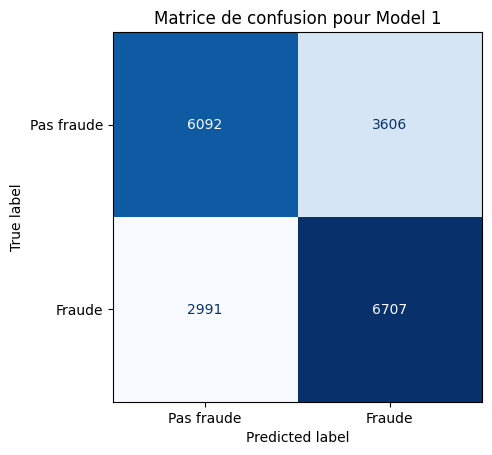

Vrais positifs : 6707
Faux positifs : 3606
Faux négatifs : 2991
Vrais négatifs : 6092


In [69]:
# TODO : Calculez et visualisez la matrice de confusion avec un heatmap
matrix=confusion_matrix(y_test, y_pred)
# TODO : Utilisez des labels clairs : ['Fraude', 'Pas fraude']
class_labels = ['Pas fraude', 'Fraude']
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(matrix, display_labels=class_labels)
disp.plot( colorbar=False, cmap='Blues')
disp.ax_.set_title('Matrice de confusion pour Model 1')
plt.show()
# TODO : Indiquez les vrais positifs, faux positifs, faux négatifs, vrais négatifs
print("Vrais positifs :", matrix[1, 1])
print("Faux positifs :", matrix[0, 1])
print("Faux négatifs :", matrix[1, 0])
print("Vrais négatifs :", matrix[0, 0])

### 5.6 Interprétation clinique de la matrice de confusion

> **Questions :**
> 1. Combien de transactions **Frauduleuses** ont été classifiées comme non frauduleuses (faux négatifs) ? Quelle est la conséquence au niveau de la banque ?
> 2. Combien de transactions **Non frauduleues** ont été classifiées comme frauduleuses (faux positifs) ? Quelle est la conséquence au niveau de la banque ?
> 3. Le modèle réduit-il les 20 % d'erreurs mentionnés par le client ?

**Vos réponses ici :**

_1. 2991 transactions Frauduleuses ont été classifiées comme non frauduleuses , la conséquence est qu'au niveau de la banque des transactions frauduleuses risques de ne pas etre  intercepté et causé beaucoup de problemes_

_2. 3606 transactions non frauduleuses ont été classifiées comme des transactions frauduleuses , cela aura pour conséquence au niveau de la banque que des transactions honetes soit bloquées par la banque ce qui peut ternir l'image de la banque auprès du public_

_3. Le modèle réduit éffectivement les erreur de classification mais devra etre optimiser avec une hyperparametrage puossé avec une gridSearchCv pour obtenir des performances encore meilleurs_

### 5.7 Courbe ROC et AUC

La courbe ROC permet d'évaluer la capacité du modèle à discriminer les deux classes à différents seuils de décision.

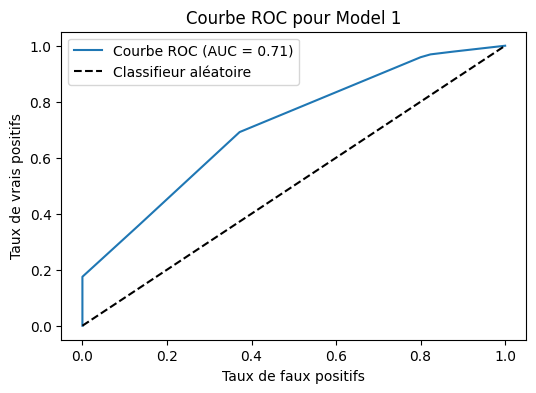

In [70]:
# TODO : Calculez les probabilités de prédiction (predict_proba) sur X_test
from sklearn.metrics import roc_curve,roc_auc_score

X_test_proba = model1.predict_proba(X_test)[:, 1]  # Probabilité de la classe positive (fraude)
# TODO : Tracez la courbe ROC et affichez la valeur de l'AUC
fpr, tpr, _ = roc_curve(y_test, X_test_proba)
auc = roc_auc_score(y_test, X_test_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Courbe ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Classifieur aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC pour Model 1')
plt.legend()
plt.show()


### 5.8 Visualisation de l'arbre retenu

Visualisez l'arbre de décision retenu pour comprendre ses règles de décision.

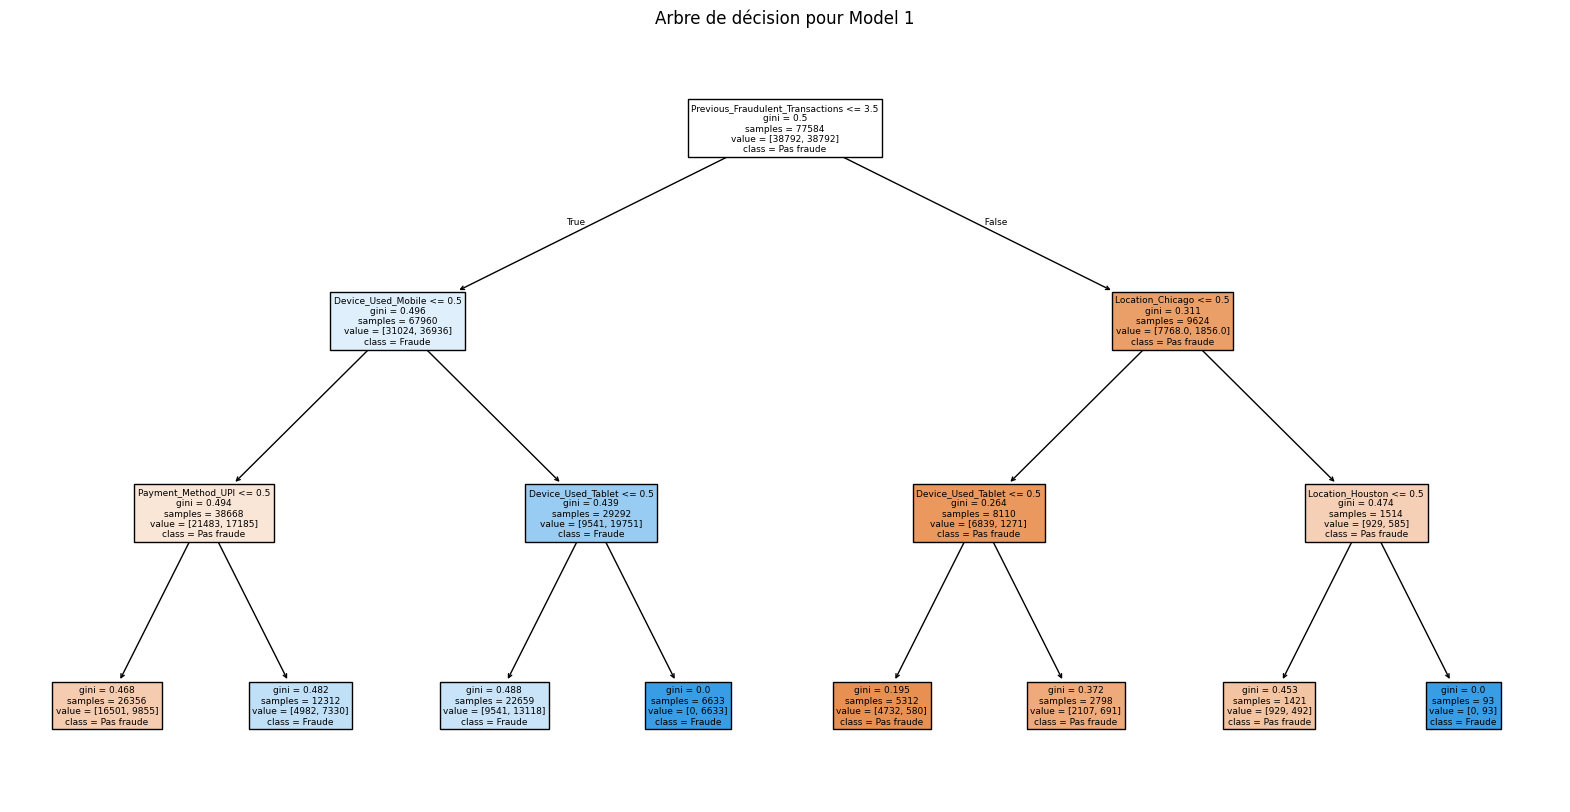

In [71]:
# TODO : Visualisez votre modèle retenu avec plot_tree de sklearn
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(model1, feature_names=X.columns, class_names=['Pas fraude', 'Fraude'], filled=True)
plt.title('Arbre de décision pour Model 1')
plt.show()
# TODO : Affichez les noms des classes ('fraude', 'pas fraude') et des caractéristiques
# TODO : Utilisez filled=True pour la coloration des noeuds


### 5.9 Importance des caractéristiques

Analysez quelles variables médicales ont le plus contribué aux décisions de l'arbre.

In [72]:
# TODO : Extrayez les importances des caractéristiques du modèle retenu
importances = model1.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# TODO : Créez un DataFrame trié par ordre décroissant d'importance
importance_df.head(10)  # Affichez les 10 caractéristiques les plus importantes

,Feature,Importance
2,Previous_Fraudulent_Transactions,0.306871
10,Device_Used_Tablet,0.279634
9,Device_Used_Mobile,0.260700
22,Payment_Method_UPI,0.121825
12,Location_Chicago,0.019925
13,Location_Houston,0.011045
0,Transaction_Amount,0.000000
6,Transaction_Type_Bill Payment,0.000000
5,Transaction_Type_Bank Transfer,0.000000
4,Number_of_Transactions_Last_24H,0.000000


C:\Users\Ce PC\AppData\Local\Temp\ipykernel_19524\36406349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


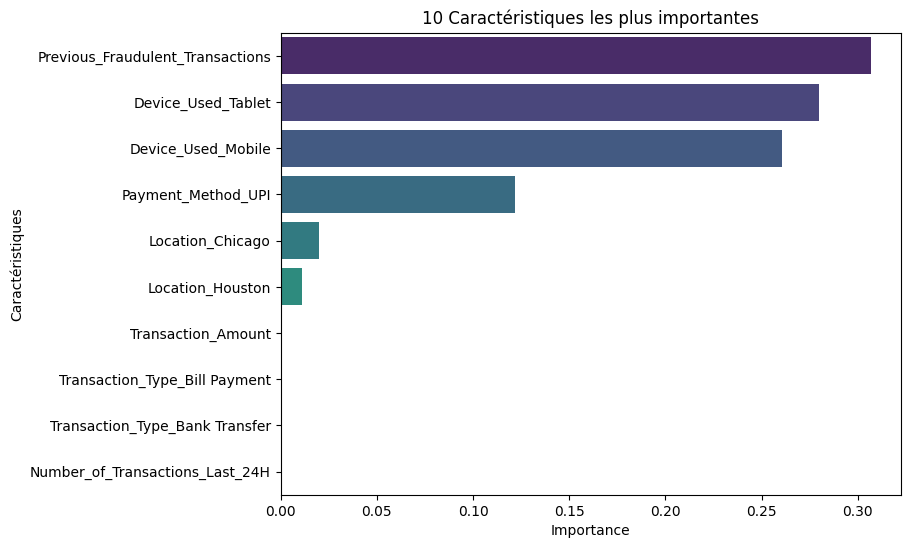

In [73]:
# TODO : Visualisez les 10 caractéristiques les plus importantes avec un barplot horizontal
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
# TODO : Ajoutez un titre et des labels d'axes clairs
plt.title('10 Caractéristiques les plus importantes')
plt.xlabel('Importance')
plt.ylabel('Caractéristiques')
plt.show()


### 5.7 Optimisation du model 3 par GridSearchCV

In [74]:
#Modele 3 : Optimisation par GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini']  # C4.5 utilise l'entropie
}
print("GridSearchCV en cours....")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_resampled,y_train_resampled)

model1 = grid_search.best_estimator_

print("\n GridSearchCV terminée")
print(f"\n Meilleurs hyperparamètres :")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Meilleur score AUC-ROC (validation croisée) : {grid_search.best_score_:.4f}")
print(f"   Profondeur du modèle optimisé : {model1.get_depth()}")
print(f"   Nombre de feuilles : {model1.get_n_leaves()}")


GridSearchCV en cours....

 GridSearchCV terminée

 Meilleurs hyperparamètres :
   criterion: gini
   max_depth: 15
   min_samples_leaf: 1
   min_samples_split: 20

 Meilleur score AUC-ROC (validation croisée) : 0.9521
   Profondeur du modèle optimisé : 15
   Nombre de feuilles : 1093


### Conclusion:
_Apres une gridSearchCV le score AUC-ROC optimal de 0.9521 apparait pour une profondeur maximale de 15_

### Analyse de l'overfitting/Underfitting
L'un des risques majeurs des arbres de décision est l'**overfitting**.  

 Calcul de l'accuracy en fonction de max_depth...


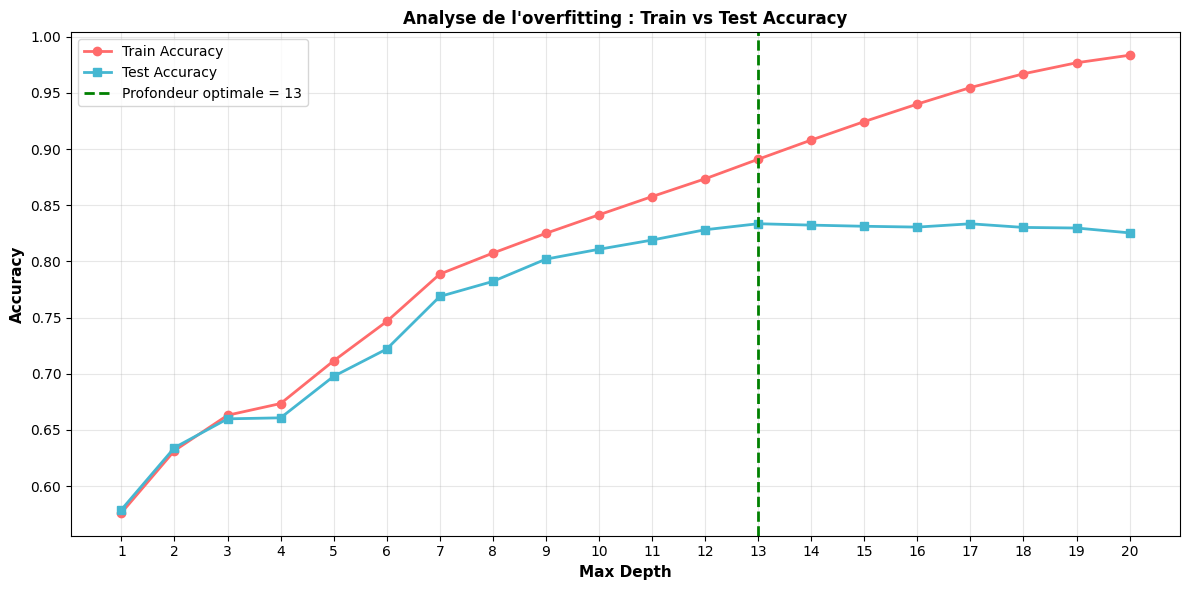


 Analyse d'overfitting :
   Profondeur optimale identifiée : 13
   Test Accuracy max : 0.8335 (à depth=13)
   À partir de depth=15, on observe une divergence train/test


In [75]:
depths = range(1, 21)
train_accs = []
test_accs = []

print(" Calcul de l'accuracy en fonction de max_depth...")
for depth in depths:
    tree = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    tree.fit(X_train_resampled, y_train_resampled)
    
    train_accs.append(accuracy_score(y_train_resampled, tree.predict(X_train_resampled)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

# Trouver la profondeur optimale (max test_acc avant divergence)
optimal_depth = depths[test_accs.index(max(test_accs))]

# Tracer
plt.figure(figsize=(12, 6))
plt.plot(depths, train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=6, color='#FF6B6B')
plt.plot(depths, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=6, color='#45B7D1')
plt.axvline(x=optimal_depth, color='green', linestyle='--', linewidth=2, label=f'Profondeur optimale = {optimal_depth}')
plt.xlabel('Max Depth', fontweight='bold', fontsize=11)
plt.ylabel('Accuracy', fontweight='bold', fontsize=11)
plt.title('Analyse de l\'overfitting : Train vs Test Accuracy', fontweight='bold', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

# Stats
print(f"\n Analyse d'overfitting :")
print(f"   Profondeur optimale identifiée : {optimal_depth}")
print(f"   Test Accuracy max : {max(test_accs):.4f} (à depth={optimal_depth})")
print(f"   À partir de depth={optimal_depth + 2}, on observe une divergence train/test")


## Phase 6 — Deployment

### 6.1 Synthèse des résultats

Complétez ce tableau de synthèse avec les résultats de votre modèle retenu :

| Critère d'évaluation | Valeur obtenue | Seuil client (objectif) |
|----------------------|---------------|------------------------|
| Accuracy globale | 83(optimisé) % | > 80 % |
| Recall — classe Fraude | 67 % | Le plus élevé possible |
| Recall — classe Pas Fraude | 67 % | — |
| AUC-ROC | 95(optimisé) | > 0.90 |
| Caractéristique la plus importante | Previous_Fraudulent_Transactions | — |
| Erreurs de classification réduites ? | Oui  | Réduction du taux de 10 % |

---

### 6.2 Recommandations au client

Répondez aux questions suivantes pour formuler vos recommandations à MedTech Solutions :

**1. Performance :** Le modèle atteint-il les objectifs définis en Phase 1 ? Sur quelle métrique vous basez-vous principalement pour répondre au probleme de la banque?

**2. Limites :** Quelles sont les limites de ce modèle ? (taille du dataset, variables non couvertes, risques de biais, etc.)

**3. Amélioration :** Quelles pistes d'amélioration proposeriez-vous ? (optimisation des hyperparamètres, autres algorithmes, enrichissement des données...)

**4. Déploiement :** Comment intégreriez-vous ce modèle dans le service médical du client ? Quel niveau d'autonomie lui accorderiez-vous par rapport au jugement du médecin ?

**Vos réponses ici :**

_1.**Performance:** Le modele a e=éfectivement atteint les objectifs fixés en phase 1. Dans le domaine d'une banque pour répondre au probleme je me consacrerai plus sur le recall plutot que sur l'accuracy_

_2.**Limites:** Le modele n'a pas encore une bonne performance pour etre aplliquer a une banque qui gere de nombreuses transactions bancaires_

_3.**Amélioration:** Pour les pistes d'amélioration on peut faire un hyperparametrage du modèle , un préprocessing plus poussé avec du feature enginering pour enrichir les données_

_4.**Déploiement:** Pour integrer le modele a une banque il faudrait crée un agent IA basé sur le modèle qui pourra jugé de la fraudulité d'une transaction avant quelle ne soit validé par les proffessionelle metier. Le model devra bien sur etre surveillé et réentrainer si nécessaire sur de nouvelles données pour maintenir ces performances voir les améliorés, Un proffessionel dvra toujours vérifier les déductions du modèle en guise de barierre d sécurité supplémentaire._

_5. **Conclusion final:** Au vue du résultat des évaluations il est claire qu'un simple modèle de DecisionTreeClassifier n'est pas assez robuste pour etre efficace sur un dataset assez complexe comme celui des transactions frauduleuses,Les performances s'ameliorent apres un hyperparametrage mes c'est encore loin d'etre suffisant pour un secteur comme le domaine bancaire.Pour garantir la fiabilité et la sécurité d'autre modèle devraont etre evaluer pour connaitre celui qui permettra de faire le moin d'erreur possible(RandomForest,KNeighborgh,LogisticRegression)_